Displaying initial records for 2005 transactions:


,county,city,zip,street,price,br,lsqft,bsqft,year,date,datesold
1,Alameda County,Alameda,94501.0,1001 Santa Clara Avenue,880000.0,7.0,5914.0,3866.0,1995.0,2005-11-06,NaN
4,Alameda County,Alameda,94501.0,1001 Shoreline Drive \#201,570000.0,2.0,39353.0,1360.0,1970.0,2005-07-31,NaN
5,Alameda County,Alameda,94501.0,1001 Shoreline Drive \#204,525000.0,2.0,39353.0,1360.0,1970.0,2005-04-17,NaN
6,Alameda County,Alameda,94501.0,1001 Shoreline Drive \#208,535000.0,2.0,39353.0,1360.0,1970.0,2005-07-17,NaN
12,Alameda County,Alameda,94501.0,1001 Shoreline Drive \#307,515000.0,2.0,39353.0,1360.0,1970.0,2005-02-13,NaN



Statistical Summary of Numerical Features:


,price,br,lsqft,bsqft
count,59148.00,45883.00,4.537400e+04,49662.00
mean,678259.98,3.02,1.113316e+05,1693.78
std,382898.00,1.08,3.817697e+06,11774.79
min,70000.00,1.00,1.900000e+01,122.00
25%,457000.00,2.00,3.960000e+03,1097.00
50%,595000.00,3.00,5.800000e+03,1428.00
75%,780000.00,4.00,8.000000e+03,1930.00
max,10000000.00,52.00,3.920400e+08,1856544.00


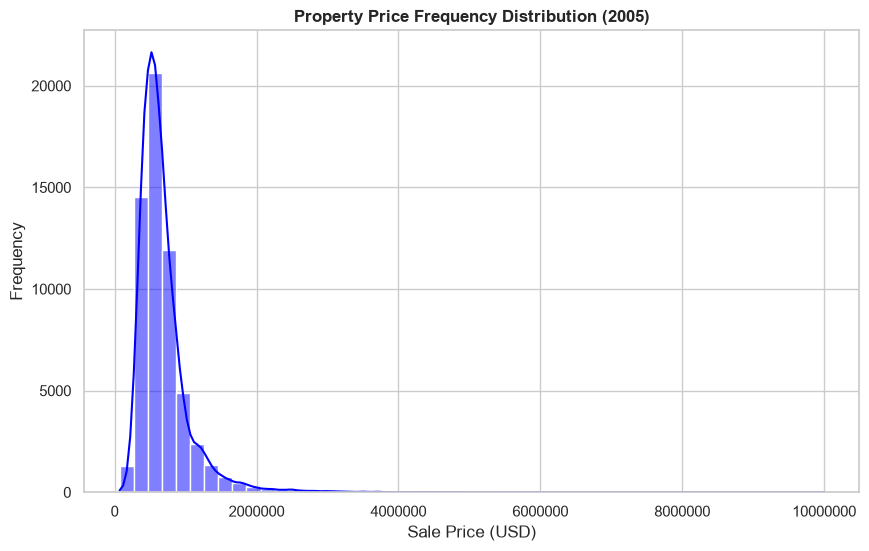

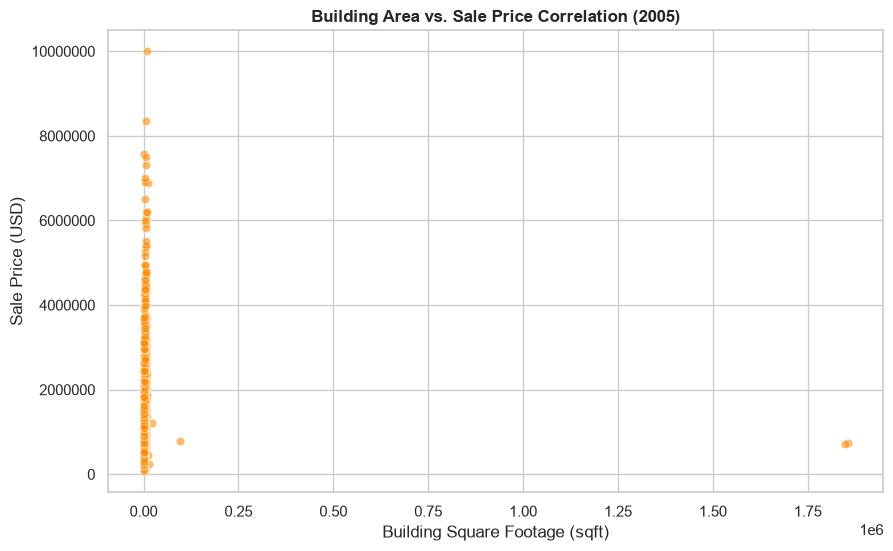

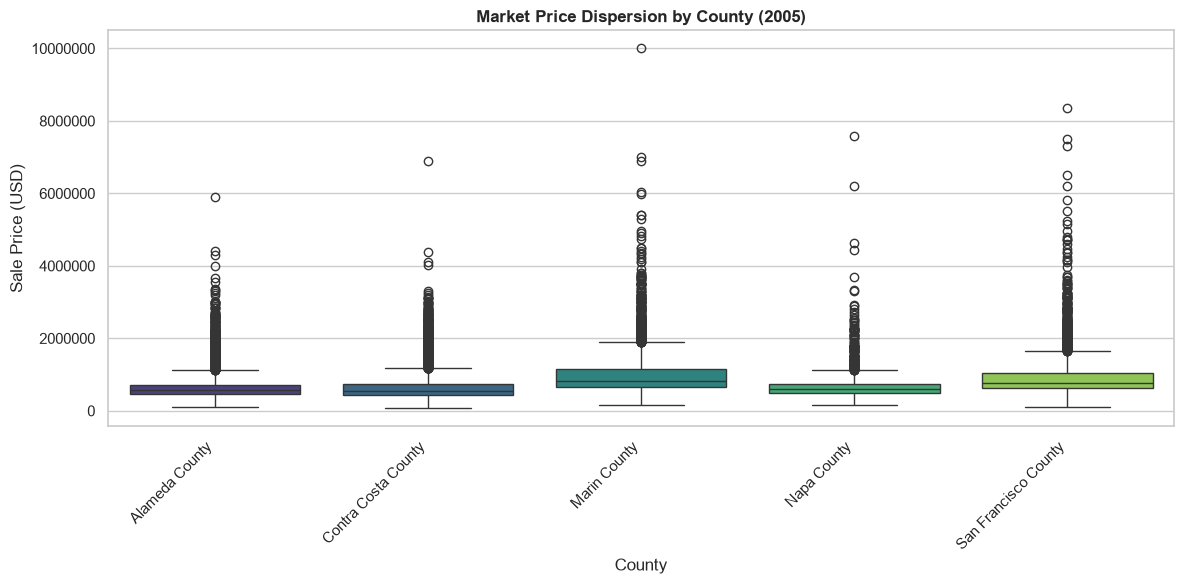

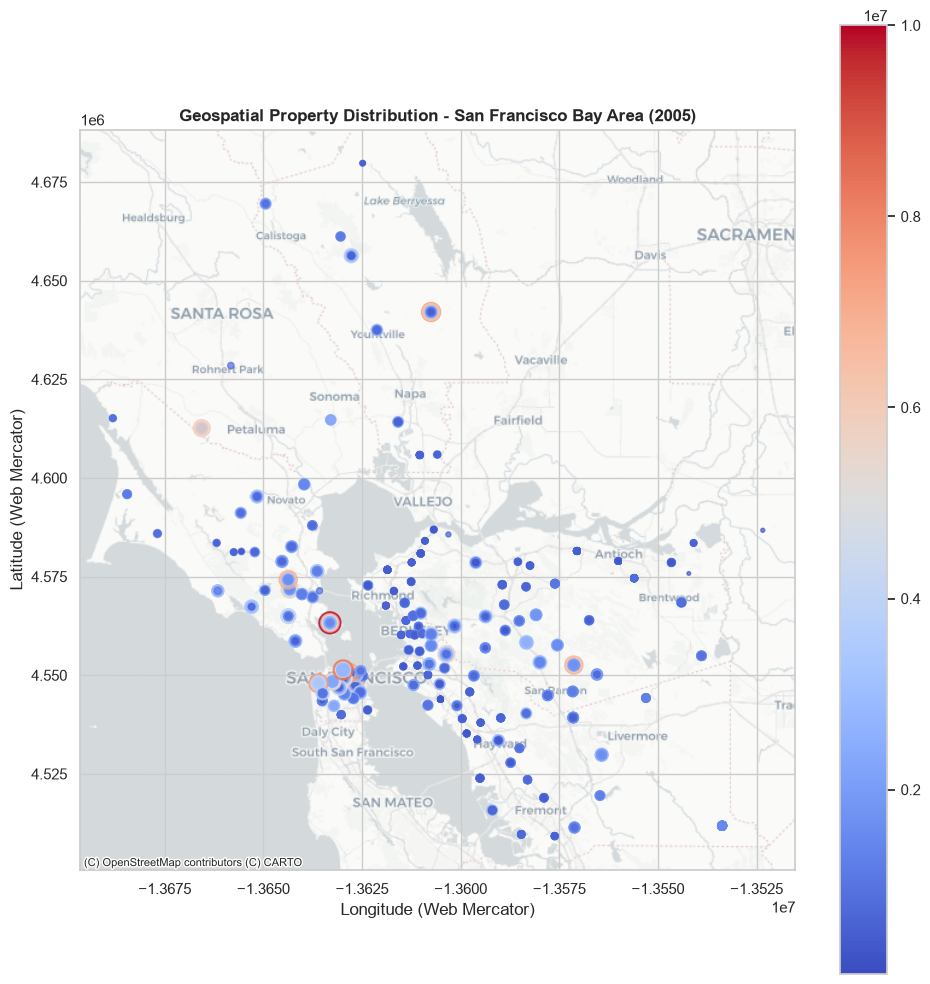

In [ ]:
"""
===============================================================================
Project: San Francisco Housing Market Exploratory Data Analysis (2005)
Author: Joao Zimmer
Description: 
    This script performs a comprehensive Exploratory Data Analysis (EDA) on a 
    real estate transactions dataset, isolating properties sold in the year 2005.

The analysis pipeline includes:
    1. Data ingestion and preprocessing (handling custom missing values & dates).
    2. Statistical profiling and description of key numerical features.
    3. Univariate and bivariate visual analyses using Matplotlib and Seaborn:
       - Price distribution (Histogram with KDE).
       - Correlation between building square footage and sale price (Scatter plot).
       - Price dispersion and outliers across different counties (Boxplot).
    4. Data enrichment and geospatial mapping: Merging local ZIP codes with public 
       coordinate repositories to render an interactive map layout with context.
===============================================================================
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set professional visual configurations for Seaborn aesthetics
sns.set_theme(style="whitegrid")

# Define the absolute file path to the dataset environment
file_path = "data_san_francisco.txt"

# Validate dataset availability before processing to prevent runtime exceptions
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please verify the directory path.")
else:
    # Load dataset, explicitly mapping 'NA' string values to pandas NaN representations
    df = pd.read_csv(file_path, na_values='NA')

    # --- Data Preprocessing ---
    # Convert date format to datetime objects to facilitate time-series filtering
    df['date'] = pd.to_datetime(df['date'])
    
    # Isolate transactions corresponding strictly to the year 2005
    df_2005 = df[df['date'].dt.year == 2005].copy()

    # Preview structural integrity of the filtered dataset
    print("Displaying initial records for 2005 transactions:")
    display(df_2005.head())

    # --- Descriptive Statistics ---
    # Select target numerical dimensions for analytical profiling
    num_cols = ['price', 'br', 'lsqft', 'bsqft']
    
    # Compute parametric descriptive statistics (central tendency and dispersion)
    stats = df_2005[num_cols].describe()

    print("\nStatistical Summary of Numerical Features:")
    display(stats.round(2))

    # --- Exploratory Data Visualization ---

    # 1. Price Distribution Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df_2005['price'].dropna(), bins=50, kde=True, color='blue')
    plt.title('Property Price Frequency Distribution (2005)', fontsize=12, fontweight='bold')
    plt.xlabel('Sale Price (USD)')
    plt.ylabel('Frequency')
    plt.ticklabel_format(style='plain', axis='x')
    plt.show()

    # 2. Scatter Plot: Building Square Footage vs. Price
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_2005, x='bsqft', y='price', alpha=0.6, color='darkorange')
    plt.title('Building Area vs. Sale Price Correlation (2005)', fontsize=12, fontweight='bold')
    plt.xlabel('Building Square Footage (sqft)')
    plt.ylabel('Sale Price (USD)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

    # 3. Boxplot: Price Dispersion across Counties
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_2005, x='county', y='price', hue='county', palette='viridis', legend=False)
    plt.title('Market Price Dispersion by County (2005)', fontsize=12, fontweight='bold')
    plt.xlabel('County')
    plt.ylabel('Sale Price (USD)')
    plt.xticks(rotation=45, ha='right')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

    # 4. Geospatial Mapping (Latitude vs. Longitude) by ZIP Code
    try:
        import contextily as ctx
        from shapely.geometry import Point
        import geopandas as gpd
        
        # Pull public geographical repository for US postal code coordinates
        url_coords = "https://gist.githubusercontent.com/erichurst/7882666/raw/5bdc46db47d9515269ab12ed6fb2850377fd869e/US%2520Zip%2520Codes%2520from%25202013%2520Government%2520Data"
        df_coords = pd.read_csv(url_coords)

        # Inner join housing records with geographic reference data on postal codes
        df_map = df_2005.merge(df_coords, left_on='zip', right_on='ZIP', how='inner')

        # Construct spatial geometry mappings and baseline GeoDataFrame (WGS84 format)
        geometry = [Point(xy) for xy in zip(df_map['LNG'], df_map['LAT'])]
        gdf = gpd.GeoDataFrame(df_map, geometry=geometry, crs="EPSG:4326")
        
        # Project spatial points into Web Mercator format required by tile providers
        gdf_mercator = gdf.to_crs(epsg=3857)

        # Initialize plotting canvas layout
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Render spatial scatter elements scaled dynamically against property pricing
        gdf_mercator.plot(
            ax=ax,
            column='price',
            cmap='coolwarm',
            markersize=df_map['price'] / 40000,
            alpha=0.7,
            legend=True
        )

        # Embed cartographic context layer (roads, topology, and regional boundaries)
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

        plt.title('Geospatial Property Distribution - San Francisco Bay Area (2005)', fontsize=12, fontweight='bold')
        plt.xlabel('Longitude (Web Mercator)')
        plt.ylabel('Latitude (Web Mercator)')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Spatial mapping routine failed to render background. Error: {e}")